Cell 1 — imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

from minicv.io import read_image
from minicv.filtering import mean_filter, gaussian_filter, median_filter
from minicv.thresholding import global_threshold, otsu_threshold, adaptive_threshold

Cell 2 — image picker

In [4]:
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.png *.jpg *.jpeg")]
    )
    root.destroy()
    return path

IMAGE_PATH = pick_image()
img_rgb  = read_image(IMAGE_PATH, mode="rgb")
img_gray = read_image(IMAGE_PATH, mode="gray")
print(f"Image loaded: {img_rgb.shape}")

Image loaded: (588, 1400, 3)


Cell 3 — mean filter

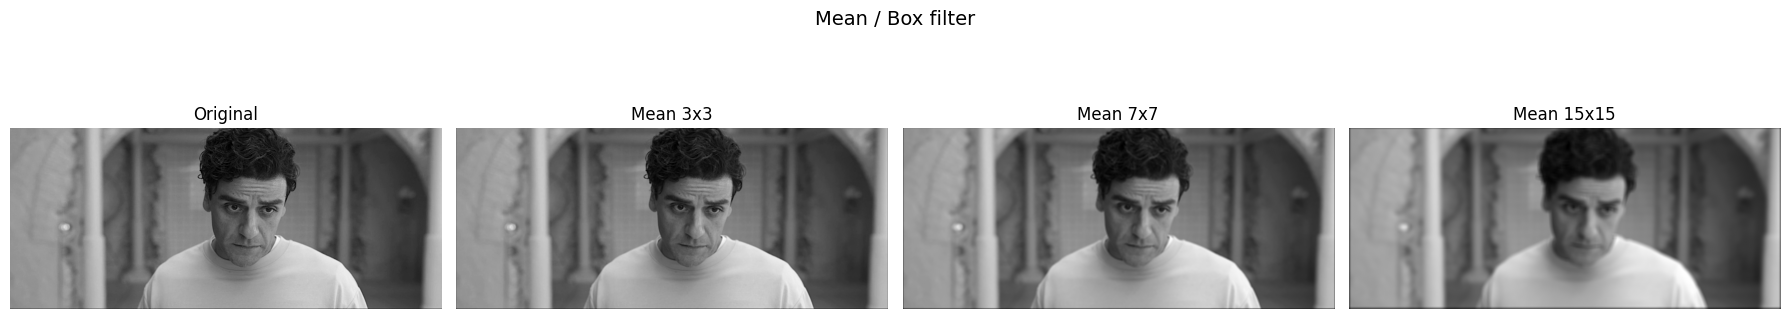

In [3]:
mean_3 = mean_filter(img_gray, kernel_size=3)
mean_7 = mean_filter(img_gray, kernel_size=7)
mean_15 = mean_filter(img_gray, kernel_size=15)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [img_gray, mean_3, mean_7, mean_15],
    ["Original", "Mean 3x3", "Mean 7x7", "Mean 15x15"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Mean / Box filter", fontsize=14)
plt.tight_layout()
plt.show()

Cell 4 — Gaussian filter

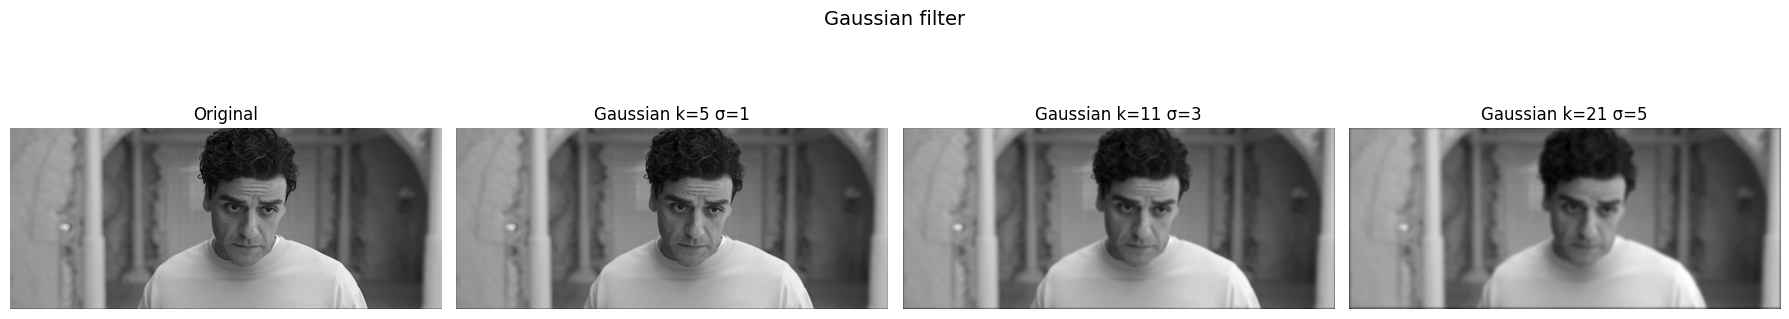

In [4]:
gauss_small  = gaussian_filter(img_gray, kernel_size=5,  sigma=1.0)
gauss_medium = gaussian_filter(img_gray, kernel_size=11, sigma=3.0)
gauss_large  = gaussian_filter(img_gray, kernel_size=21, sigma=5.0)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [img_gray, gauss_small, gauss_medium, gauss_large],
    ["Original", "Gaussian k=5 σ=1", "Gaussian k=11 σ=3", "Gaussian k=21 σ=5"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Gaussian filter", fontsize=14)
plt.tight_layout()
plt.show()

Cell 5 — Gaussian on RGB

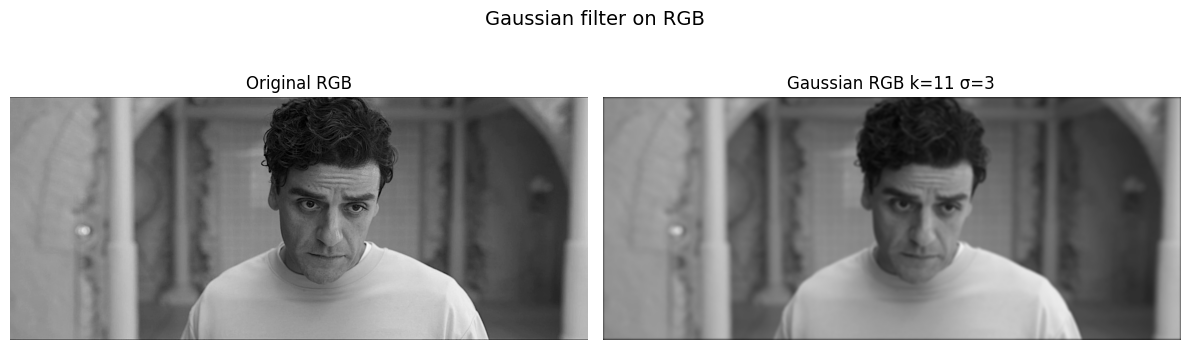

In [6]:
gauss_rgb = gaussian_filter(img_rgb.astype(np.float64), kernel_size=11, sigma=3.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(np.clip(gauss_rgb, 0, 255).astype(np.uint8))
axes[1].set_title("Gaussian RGB k=11 σ=3")
axes[1].axis("off")

plt.suptitle("Gaussian filter on RGB", fontsize=14)
plt.tight_layout()
plt.show()

Cell 6 — median filter

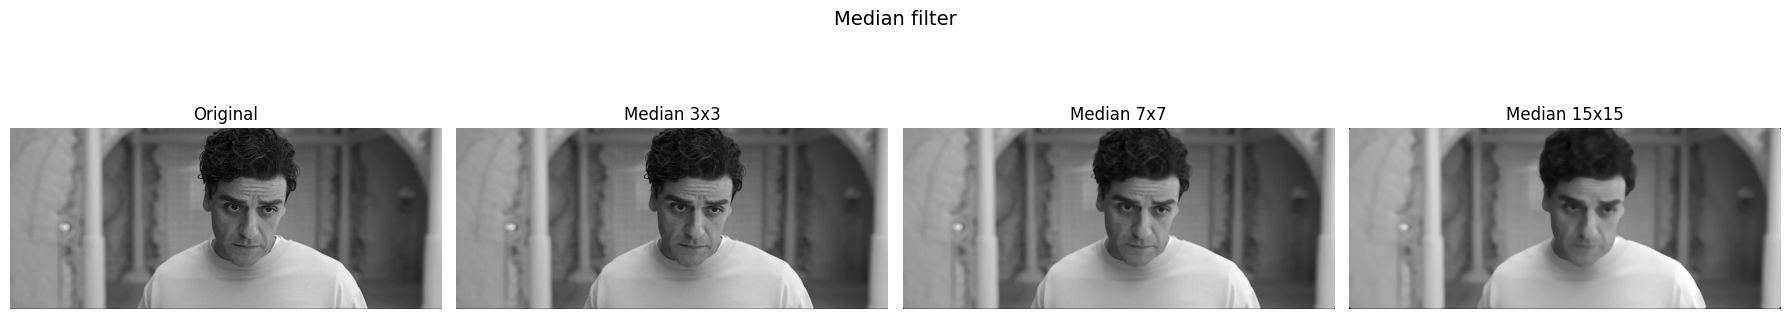

In [5]:
median_3  = median_filter(img_gray, kernel_size=3)
median_7  = median_filter(img_gray, kernel_size=7)
median_15 = median_filter(img_gray, kernel_size=15)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [img_gray, median_3, median_7, median_15],
    ["Original", "Median 3x3", "Median 7x7", "Median 15x15"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Median filter", fontsize=14)
plt.tight_layout()
plt.show()

Cell 7 — filter comparison (noise removal)

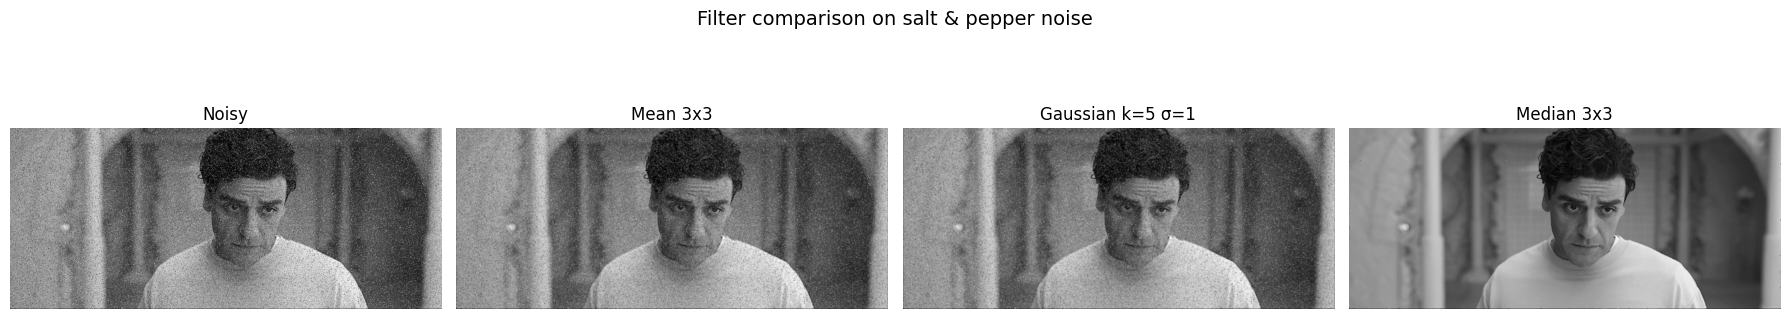

In [5]:
# Add salt & pepper noise
noisy = img_gray.copy().astype(np.float64)
rng = np.random.default_rng(42)
noise_mask = rng.random(noisy.shape)
noisy[noise_mask < 0.05] = 0
noisy[noise_mask > 0.95] = 255

mean_denoised   = mean_filter(noisy.astype(np.uint8),   kernel_size=3)
gauss_denoised  = gaussian_filter(noisy,                kernel_size=5, sigma=1.0)
median_denoised = median_filter(noisy.astype(np.uint8), kernel_size=3)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [noisy, mean_denoised, gauss_denoised, median_denoised],
    ["Noisy", "Mean 3x3", "Gaussian k=5 σ=1", "Median 3x3"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Filter comparison on salt & pepper noise", fontsize=14)
plt.tight_layout()
plt.show()

Cell 8 — global threshold

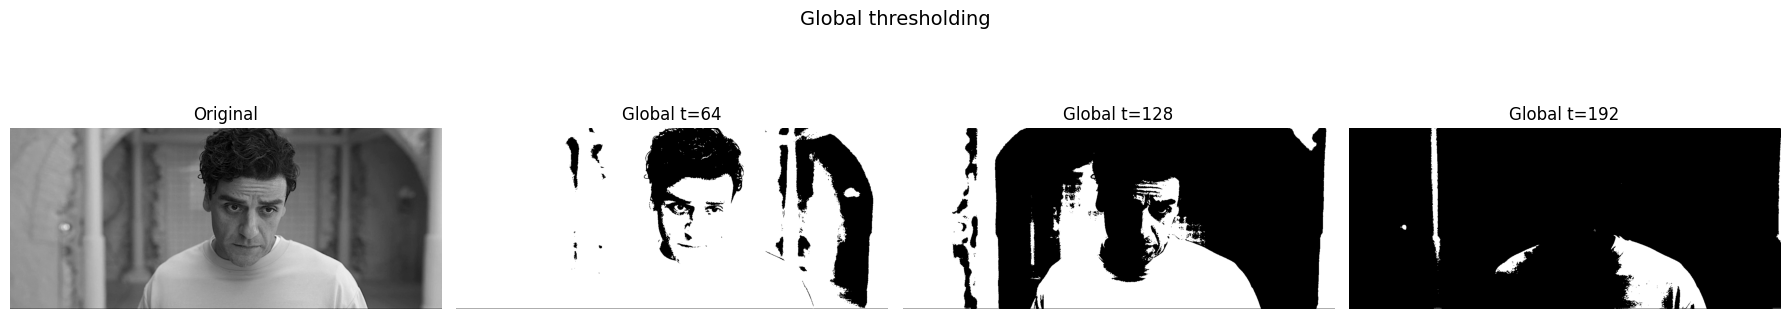

In [7]:
thresh_64  = global_threshold(img_gray, threshold=64)
thresh_128 = global_threshold(img_gray, threshold=128)
thresh_192 = global_threshold(img_gray, threshold=192)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [img_gray, thresh_64, thresh_128, thresh_192],
    ["Original", "Global t=64", "Global t=128", "Global t=192"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Global thresholding", fontsize=14)
plt.tight_layout()
plt.show()

Cell 9 — Otsu threshold

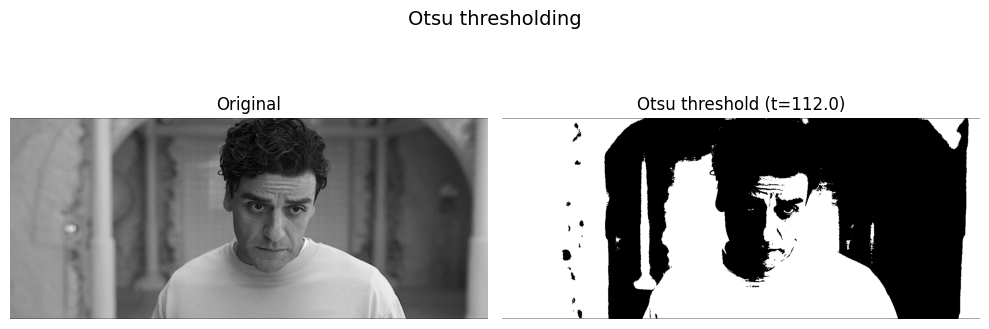

In [8]:
binary_otsu, t = otsu_threshold(img_gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary_otsu, cmap="gray")
axes[1].set_title(f"Otsu threshold (t={t:.1f})")
axes[1].axis("off")

plt.suptitle("Otsu thresholding", fontsize=14)
plt.tight_layout()
plt.show()

Cell 10 — adaptive threshold

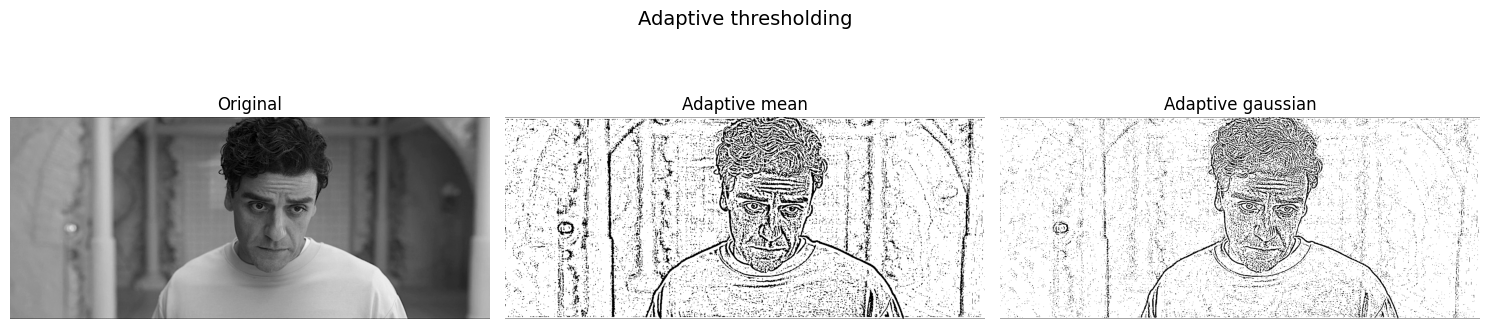

In [9]:
adaptive_mean = adaptive_threshold(img_gray, block_size=11, C=2, method="mean")
adaptive_gauss = adaptive_threshold(img_gray, block_size=11, C=2, method="gaussian")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, title in zip(axes,
    [img_gray, adaptive_mean, adaptive_gauss],
    ["Original", "Adaptive mean", "Adaptive gaussian"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Adaptive thresholding", fontsize=14)
plt.tight_layout()
plt.show()

Cell 11 — all thresholds compared

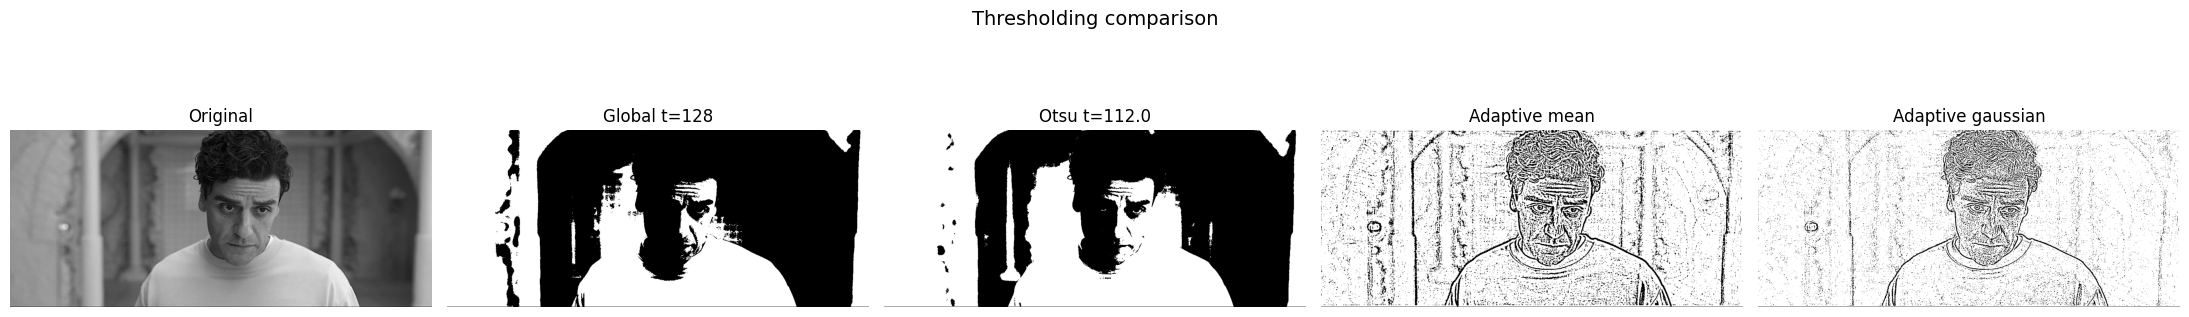

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, img, title in zip(axes,
    [img_gray, thresh_128, binary_otsu, adaptive_mean, adaptive_gauss],
    ["Original", "Global t=128", f"Otsu t={t:.1f}", "Adaptive mean", "Adaptive gaussian"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Thresholding comparison", fontsize=14)
plt.tight_layout()
plt.show()